In [5]:
import os
from dotenv import load_dotenv
from typing import List, Annotated
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
load_dotenv()

True

In [6]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-4o-mini")

In [9]:
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [10]:
retriever.invoke("what are autonomous agents")

[Document(id='e7942231-6ee1-415a-9c84-553050cdf023', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [11]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [12]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


"Tool use\n\nThe agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), including current information, code execution capability, access to proprietary information sources and more.\n\n\n\n\n\nOverview of a LLM-powered autonomous agent system.\nCitation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\nLLM Powered Autonomous Agents | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponen

In [13]:
retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [14]:
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\kumar\\Desktop\\anaco\\envs\\agentic\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

C:\Users\kumar\AppData\Local\Temp\ipykernel_12952\1566594096.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(llm,tools)


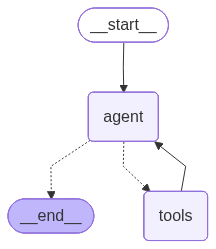

In [15]:
tools = [retriever_tool, wiki_tool]
react_node=create_react_agent(llm,tools)
react_node

In [16]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

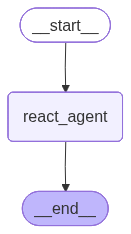

In [17]:
builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [18]:
if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool

✅ Final Answer:
 ### What is an Agent Loop?

An agent loop is a system in which an autonomous agent continuously processes information and makes decisions based on that information. The agent can learn to call external APIs to gather additional information that might be necessary for performing complex tasks. This is particularly useful for large language model (LLM)-powered autonomous agents, as they extend their capabilities beyond just generating content by performing problem-solving tasks. Key components of such a system include:

- **Planning**: The agent decomposes tasks and may engage in self-reflection.
- **Memory**: Different types of memory can be utilized to enhance the agent's decision-making process.

These loops allow agents to solve problems autonomously, making them more effective in real-world applications.

### Wikipedia's Description of Autonomous Agents

According to Wikipedia, an **autonomous agent** is defined as an artificial intelligen

In [21]:
if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1])

📚 Using RAGRetriever tool

✅ Final Answer:
 content="An **agent loop** often refers to the iterative process that an autonomous agent goes through in order to perceive its environment, decide on actions, and then act based on those perceptions and decisions. In the context of large language model (LLM)-powered systems, this typically involves the agent learning to call external APIs for additional information that may not be contained within its pre-trained model weights. This process allows the agent to dynamically adapt and enhance its problem-solving capabilities.\n\n### Wikipedia's Description of Autonomous Agents\nAccording to the information retrieved:\n\n- An **autonomous agent** is defined as an artificial intelligence (AI) system capable of performing complex tasks independently.\n- In a broader sense, **intelligent agents** are entities that perceive their environment and take actions autonomously to achieve specific goals. They can improve their performance through machine l